
[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\palak\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8343.57it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


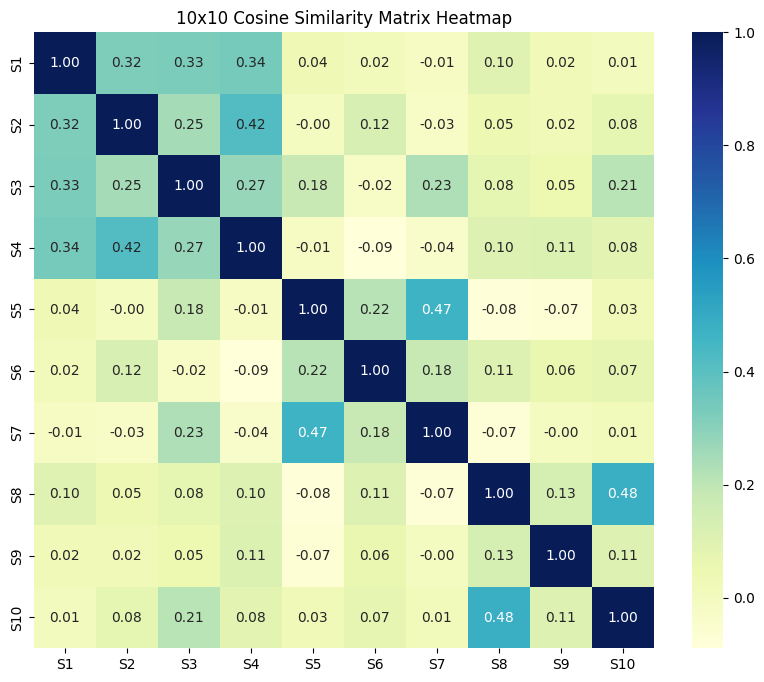

Query: The bowler took three wickets in one over

Top 2 Most Similar Sentences:
- Sentence: The batsman hit a massive six over the deep mid-wicket boundary.
  Similarity Score: 0.5753
- Sentence: The spin bowler deceived the player with a perfectly disguised googly.
  Similarity Score: 0.4671


In [1]:
# 1. Install necessary libraries
!pip install sentence-transformers matplotlib seaborn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

# 2. Define 10 sentences across 3 topics (Cricket, Cooking, Cybersecurity)
sentences = [
    # Cricket
    "The batsman hit a massive six over the deep mid-wicket boundary.",
    "Fielding at slip requires immense concentration and quick reflexes.",
    "The spin bowler deceived the player with a perfectly disguised googly.",
    "Test cricket is considered the ultimate challenge for professional athletes.",
    # Cooking
    "Slowly sauté the onions until they are caramelized and golden brown.",
    "A pinch of saffron can drastically enhance the aroma and color of the rice.",
    "Whisk the eggs and sugar together until the mixture becomes light and fluffy.",
    # Cybersecurity
    "Multi-factor authentication adds a critical layer of security to sensitive accounts.",
    "A firewall monitors and controls incoming and outgoing network traffic.",
    "Phishing attacks often use deceptive emails to steal user credentials."
]

# 3. Load the specific model and generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

# 4. Compute 10x10 Cosine Similarity Matrix
cosine_sim_matrix = util.cos_sim(embeddings, embeddings).numpy()

# 5. Display Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim_matrix, annot=True, cmap='YlGnBu', fmt=".2f",
            xticklabels=[f"S{i+1}" for i in range(10)],
            yticklabels=[f"S{i+1}" for i in range(10)])
plt.title("10x10 Cosine Similarity Matrix Heatmap")
plt.show()

# 6. Find most similar sentences for the new query
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query)

# Compute similarity between query and all sentences
similarities = util.cos_sim(query_embedding, embeddings)[0]

# Get indices of top 2 most similar sentences
top_results = np.argsort(similarities.numpy())[::-1][:2]

print(f"Query: {query}\n")
print("Top 2 Most Similar Sentences:")
for idx in top_results:
    print(f"- Sentence: {sentences[idx]}")
    print(f"  Similarity Score: {similarities[idx]:.4f}")